In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data
from skimage.util import random_noise

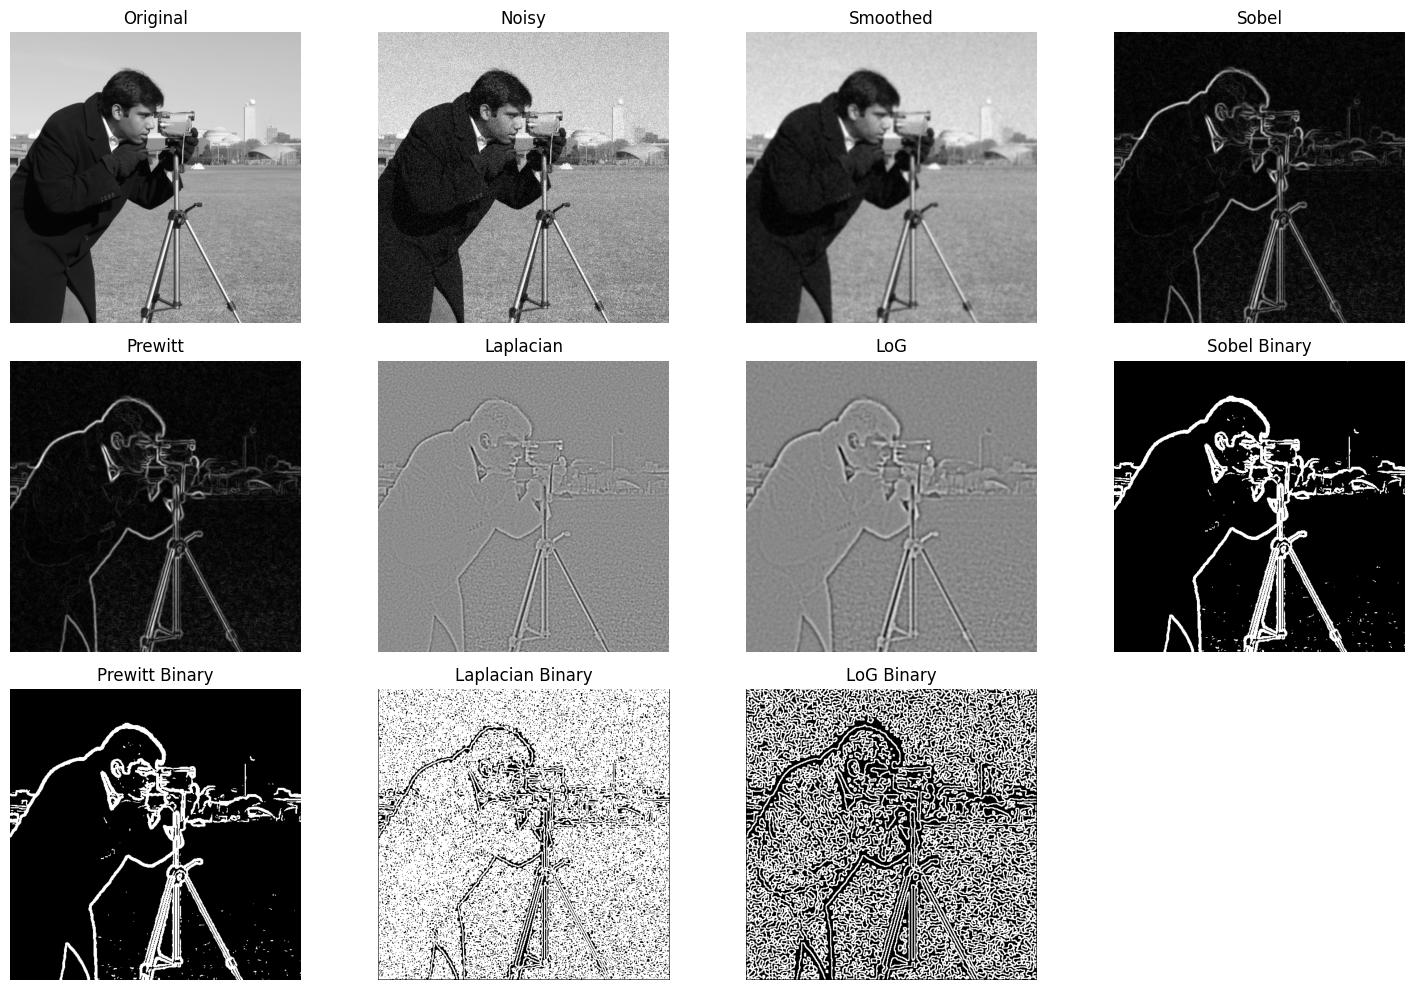

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data
from skimage.util import random_noise
from skimage.filters import gaussian

# ===============================
# 1)ADD Noise to imag
# ===============================
img = data.camera()

noisy = (random_noise(img, mode='gaussian', var=0.005) * 255).astype(np.uint8)

# ===============================
# 2) Smoothing
# ===============================
smoothed = gaussian(noisy, sigma=1.5, preserve_range=True).astype(np.uint8)

# ===============================
# 3) Edge Detection Filters
# ===============================
# Sobel
sx = ndimage.sobel(smoothed.astype(float), axis=0)
sy = ndimage.sobel(smoothed.astype(float), axis=1)
sobel = np.hypot(sx, sy)


px = ndimage.prewitt(smoothed.astype(float), axis=0)
py = ndimage.prewitt(smoothed.astype(float), axis=1)
prewitt = np.hypot(px, py)


lap = ndimage.laplace(smoothed.astype(float))


log = ndimage.gaussian_laplace(smoothed.astype(float), sigma=2)


def threshold(f):
    T = np.percentile(f, 90)
    return f > T

sobel_bin = threshold(sobel)
prewitt_bin = threshold(prewitt)

# ===============================
# 5) Zero Crossing (2nd derivative)
# ===============================
def zero_cross(f):
    zc = np.zeros_like(f, dtype=bool)

    for i in range(1, f.shape[0]-1):
        for j in range(1, f.shape[1]-1):
            patch = f[i-1:i+2, j-1:j+2]
            if (patch.max() > 0 and patch.min() < 0):
                zc[i, j] = True

    return zc

lap_bin = zero_cross(lap)
log_bin = zero_cross(log)


titles = [
    "Original", "Noisy", "Smoothed",
    "Sobel", "Prewitt", "Laplacian", "LoG",
    "Sobel Binary", "Prewitt Binary",
    "Laplacian Binary", "LoG Binary"
]

images = [
    img, noisy, smoothed,
    sobel, prewitt, lap, log,
    sobel_bin, prewitt_bin,
    lap_bin, log_bin
]

plt.figure(figsize=(15, 10))

for i in range(len(images)):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()